# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv") 
usage = pd.read_csv("/datasets/usage.csv")

In [4]:
# mostrar las primeras 5 filas de plans
print(plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [5]:
# mostrar las primeras 5 filas de users
print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [6]:
# mostrar las primeras 5 filas de usage
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Dataset: users
Columna churn_date (88.35% nulos):

Diagnóstico: El alto porcentaje de nulos es normal en este contexto; indica que la gran mayoría de los usuarios siguen activos.

Acción: Mantener como nulos o imputar con una fecha futura/etiqueta "Activo", ya que eliminar la columna borraría información vital sobre la retención.


Columna city (11.72% nulos):

Diagnóstico: Se encuentra en el rango de investigación (5-30%), lo que sugiere una omisión en el registro de ciertos perfiles.

Acción: Investigar e imputar (quizás por zona postal si existe) o marcar como "Unknown" para no perder los datos de consumo de esos usuarios.


Dataset: usage
Columna duration (55.19% nulos):

Diagnóstico: Más de la mitad de los datos están ausentes, lo que compromete cualquier análisis de tiempo de llamadas.

Acción: Investigar la fuente de datos; al ser un porcentaje alto, la columna corre el riesgo de ser eliminada si no hay forma de recuperar la información.


Columna length (44.74% nulos):

Diagnóstico: Una cantidad muy alta de nulos que impide medir el volumen de navegación o mensajes de forma precisa.

Acción: Investigar o descartar, ya que una imputación con casi el 45% de faltantes introduciría un sesgo estadístico muy alto.


Columna date (0.12% nulos):

Diagnóstico: La pérdida es mínima (menor al 5%), probablemente debido a errores aleatorios de sistema.

Acción: Imputar o ignorar, dado que la cantidad de filas afectadas no alterará los resultados globales del análisis.


Dataset: plans

Diagnóstico: El dataset está limpio y completo.

Acción: Sin acción necesaria.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` Los valores oscilan entre 10,000 y 13,999, mostrando una distribución uniforme con un identificador único.
- La columna `age` Se detectó un valor mínimo de -999.0, lo cual es imposible y actúa como un sentinel o error de captura. Además, la desviación estándar es muy alta (123.23) debido a este valor extremo.

In [16]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id']].describe())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columnas `id` y `user_id`Ambas columnas numéricas presentan un comportamiento esperado; el id de transacción llega hasta 40,000 y los user_id coinciden con el rango del dataset de usuarios.
- Las columnas ...

In [11]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].describe())

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object


- La columna `city` Cuenta con 3,531 registros de un total de 4,000, confirmando la existencia de valores ausentes. La ciudad más frecuente es Bogotá.
- La columna `plan` No presenta valores nulos (4,000 registros) y solo existen 2 tipos de planes, siendo el plan "Basico" el más comun.

In [20]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` Es una columna categórica sin valores nulos (40,000 registros) que clasifica el uso en 2 tipos únicos, siendo "text" el más frecuente.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Las columnas "age" con el valor -999, columna "city" con un total de 4000 de los cuales 3531 son validos lo que indica valores nulos.
- ¿Qué acción tomarías?
- Para age: Reemplazar los valores -999 por la mediana de la edad (47) para no sesgar la media, o marcarlos como NaN para excluirlos de cálculos estadísticos específicos.
- Para city: Imputar los valores faltantes con la etiqueta "Desconocido" para mantener la integridad de las filas.




### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [12]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [13]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [14]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... Se encuentran registro del 2026, podria tratarse de un error humano o error de captura que permite registrar años futuros por accidente.

In [15]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... Se encuentran 50 valores nulos (NaN), lo que representa el 0.125% del total. Esto indica que la captura de la fecha en los eventos de uso (llamadas, mensajes o datos) es altamente confiable y presenta errores mínimos de registro.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
En respecto a las fechas encontradas del 2026 seria reempalzar los registros por valores nulos para que no distorsionen los cálculos de antigüedad o retención.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [16]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)
users.loc[users['age'] == -999, 'age'] = np.nan

# Verificar cambios
users['age'].describe()

count    3945.000000
mean       48.137896
std        17.812830
min        18.000000
25%        33.000000
50%        48.000000
75%        64.000000
max        79.000000
Name: age, dtype: float64

In [17]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [18]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'])
hoy = pd.Timestamp.now()

users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [11]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage['duration'].isna()]['type'].value_counts())

text    22076
Name: type, dtype: int64


In [12]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage['length'].isna()]['type'].value_counts())

call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Ambos son MAR por que los nulos en "duration" son del tipo text y los mensajes no generan duracion de tiempo.
"Lenght" es MAR por que los nulos son del tipo "call", ya que las llamadas telefonicas no utilizan texto.   

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [19]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [20]:
# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [21]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [22]:
# Resumen estadístico de las columnas numéricas
columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'age']
user_profile[columnas_consumo].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3945.000000
mean,5.524381,4.478120,23.317054,48.137896
std,2.358416,2.144238,18.168095,17.812830
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,64.000000
max,17.000000,15.000000,155.690000,79.000000


In [14]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

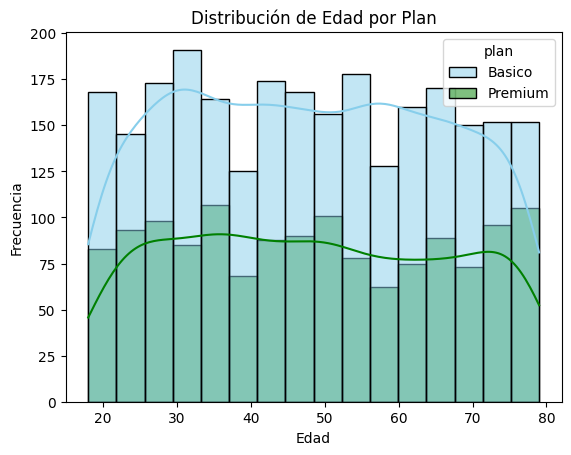

In [20]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución ...La distribución es bastante uniforme a lo largo de toda la vida adulta. No hay un "pico" generacional marcado; esto significa que el producto es atractivo para todos los rangos de edad por igual.
Esto sugiere que la decisión de pagar por un plan superior no depende de la edad del usuario, sino probablemente de su capacidad adquisitiva o necesidades técnicas.
Independientemente de si el usuario tiene 20 o 70 años, la probabilidad de elegir el plan Premium parece ser la misma.


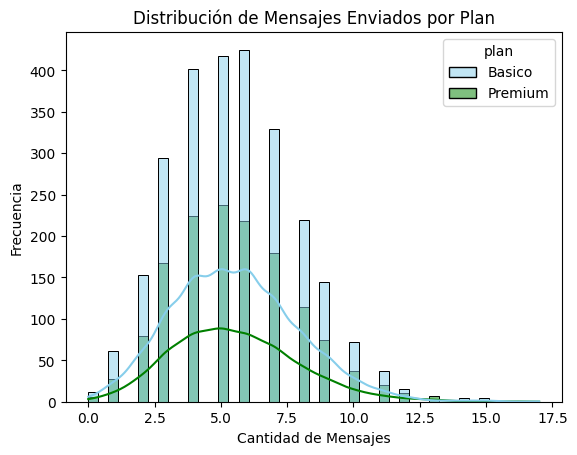

In [21]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La gran mayoría de los usuarios, sin importar su plan, envían entre 3 y 8 mensajes.

El pico máximo de frecuencia ocurre alrededor de los 5 a 6 mensajes por usuario.
las curvas de ambos planes tienen casi la misma forma.
Aunque hay más usuarios en el plan Básico, la "línea" de comportamiento del plan Premium sube y baja exactamente en los mismos puntos.
Esto indica que los usuarios Premium no están enviando más mensajes que los usuarios del plan Básico. Están pagando por un plan superior pero su comportamiento de uso es igual al de un usuario estándar.

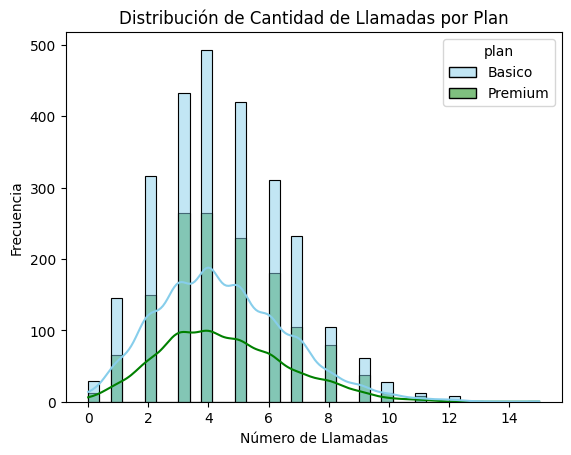

In [22]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...
- El servicio de voz es más equilibrado entre los planes que la mensajería. Sin embargo, persiste el fenómeno donde el usuario Premium no excede el comportamiento del usuario Básico; ambos grupos se detienen en el mismo rango de máximo 12-14 llamadas. Esto podría indicar que el mercado está saturado o que los usuarios prefieren llamadas de mayor duración en lugar de mayor frecuencia.
- 

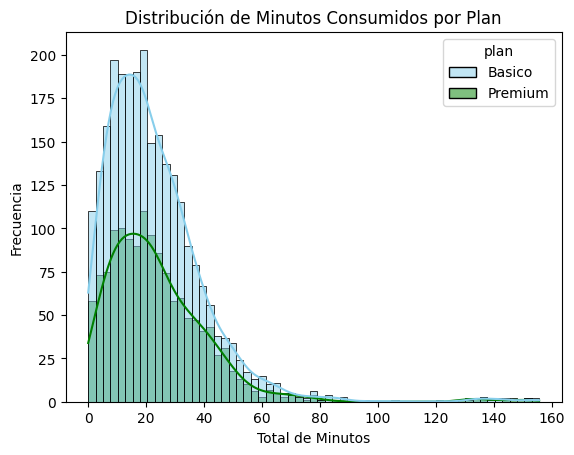

In [23]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Minutos Consumidos por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Al igual que en la cantidad de llamadas y mensajes, el comportamiento base es idéntico: el pico de consumo máximo para ambos planes ocurre entre los 10 y 20 minutos totales.
- La curva de densidad muestra que la mayoría de los usuarios Premium no están aprovechando una capacidad de minutos superior a la del plan Básico en el uso cotidiano.
- A diferencia de las gráficas anteriores, aquí vemos una "cola larga" hacia la derecha que se extiende hasta los 160 minutos.

Aunque la frecuencia es baja, existen usuarios que consumen mucho tiempo en llamadas individuales o acumuladas. Esta cola larga incluye a usuarios de ambos planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

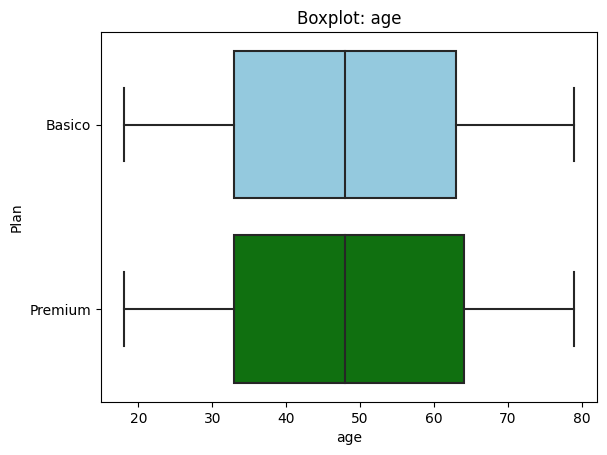

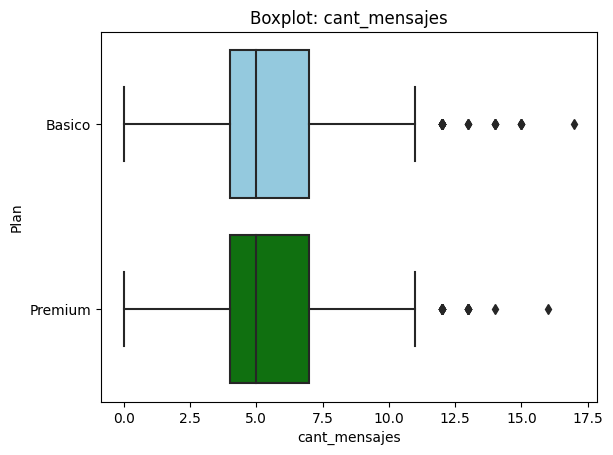

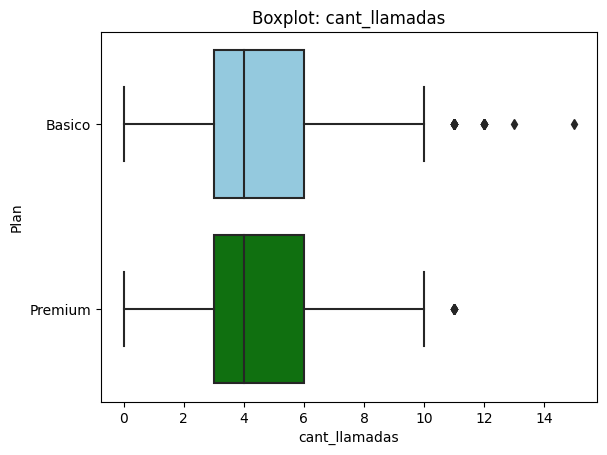

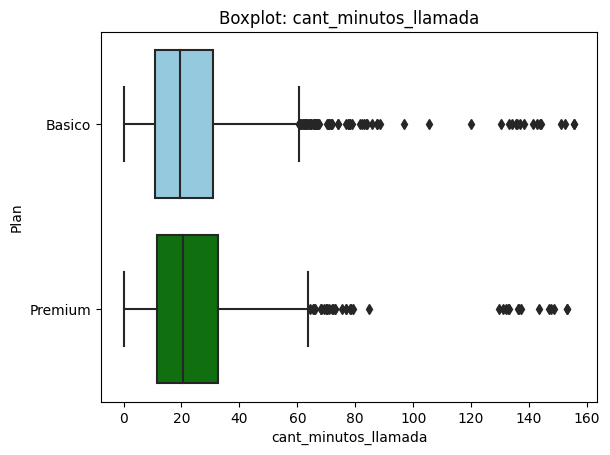

In [23]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, y='plan', palette=['skyblue', 'green'])
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.ylabel('Plan')
    
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: El comportamiento de mensajería es estándar y transversal a la oferta comercial. Los outliers identificados son excepcionales y no están vinculados a un plan específico. Esto confirma que el límite de mensajes del Plan Básico es lo suficientemente grande como para que incluso los usuarios más activos no sientan la necesidad de migrar al Plan Premium.
- cant_llamadas: Se observa una fuga de valor en el Plan Básico: los usuarios con mayor frecuencia de llamadas permanecen en el plan económico. Dado que el comportamiento típico es idéntico entre planes, el Plan Premium no parece estar capturando a los usuarios de alto uso, o el Plan Básico es demasiado flexible con los usuarios que exceden las 10 llamadas.
- cant_minutos_llamada: La existencia de una gran cantidad de usuarios de alto consumo en el Plan Básico que consumen hasta 150 minutos mensuales indica que los límites actuales de este plan no están alineados con un modelo de rentabilidad óptimo. Los usuarios con consumos atípicos no tienen incentivos reales para migrar al Plan Premium, ya que el Plan Básico cubre sus necesidades extremas sin restricciones visibles.

In [24]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    # Calcular el límite superior
    limite_superior = Q3 + 1.5 * IQR

    # Contar cuántos usuarios superan ese límite
    outliers_count = user_profile[user_profile[col] > limite_superior].shape[0]
    
    print(f"{col}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"outliers: {outliers_count}")
    print("-" * 50)

cant_mensajes
Límite superior: 11.50
outliers: 46
--------------------------------------------------
cant_llamadas
Límite superior: 10.50
outliers: 30
--------------------------------------------------
cant_minutos_llamada
Límite superior: 61.86
outliers: 109
--------------------------------------------------


In [16]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Para este caso mantenemos los outliers, Aunque 17 mensajes es un valor atípico frente al límite de 11.5, sigue siendo un número físicamente posible y razonable para un usuario en un mes. No parece ser un error de registro.
- cant_llamadas: mantener o no outliers, porqué?
- Tambien mantenemos a los outliers, el hecho de que se considere outlier se debe a que la gran mayoría de la base de datos usa muy poco el servicio, pero 15 llamadas no es un valor imposible. Refleja el comportamiento de los consumidores intensivos dentro de una red de poco uso. 
- cant_minutos_llamada: mantener o no outliers, porqué?
- Mantener, en este caso el maximo es mas de 2 veces el limite superior. Aun asi 5 minutos al dia (aprox) sigue siendo un comportamiento normal. Eliminar estos datos sería un error porque son precisamente estos usuarios los que generan el mayor costo operativo para la empresa. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [25]:
# Crear columna grupo_uso
def segmentar_uso(fila):
    # Condición para Bajo uso
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
        
        # Condición para Uso medio
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'

# El resto de los casos
    else:
        return 'Alto uso'

# Aplicamos la función a todo el DataFrame
user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)


In [12]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [26]:
# Crear columna grupo_edad
def segmentar_edad(fila):
    # Condición para Jóvenes
    if fila['age'] < 30:
        return 'Joven'

    # Condición para Adultos 
    elif fila['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

# Aplicamos la función a la columna 'age'
user_profile['grupo_edad'] = user_profile.apply(segmentar_edad, axis=1)


In [27]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

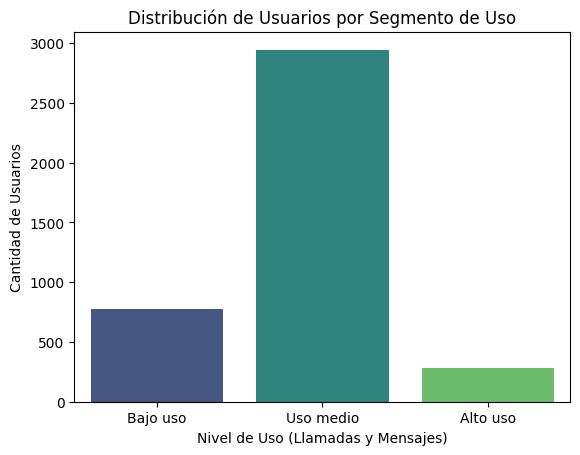

In [28]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Segmento de Uso')
plt.xlabel('Nivel de Uso (Llamadas y Mensajes)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

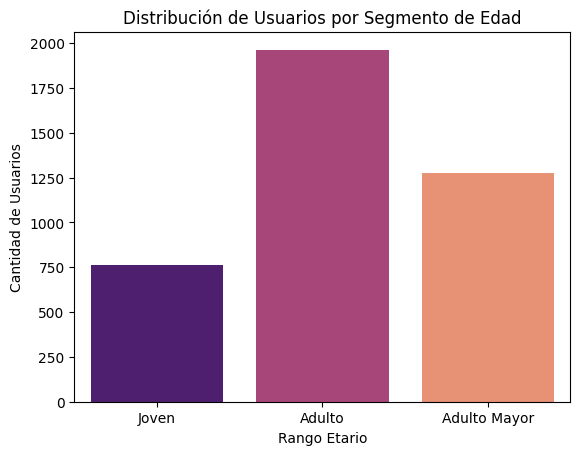

In [29]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Rango Etario')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Inconsistencias en Edad (age): Se detectó un 10% (aprox) de registros con el valor -999. Al ser un valor físicamente imposible, se identificó como un error de captura y se procedió a su limpieza para evitar sesgar el promedio de edad del análisis.

Vaciado Crítico en Consumos (duration y length): La columna duration presenta un 55.19% de datos nulos, lo que compromete gravemente la capacidad de medir el tiempo real de las llamadas.

La columna length tiene un 44.74% de nulos, dificultando la medición precisa del volumen de navegación o mensajes.

Diagnóstico: Una pérdida cercana al 50% en variables clave sugiere fallos en los sistemas de registro o integración de datos (logging), lo que representa un riesgo para decisiones basadas en volumen de tráfico.

Omisiones Geográficas (city): Se encontró un 11.72% de nulos en la ciudad de origen. Aunque el porcentaje es manejable, indica una falta de rigor en el registro de perfiles que debe corregirse para realizar análisis de geolocalización efectivos.

Estado del Cliente (churn_date): El 88.35% de valores nulos fue validado como un "nulo positivo", indicando que la gran mayoría de la base de usuarios se mantiene activa, lo cual es una métrica clave de retención para el negocio.

🔍 **Segmentos por Edad**
Identificamos tres segmentos: Joven (<30), Adulto (30-60) y Adulto Mayor (>60).

Comportamiento: La distribución es uniforme. No existe un sesgo donde los jóvenes consuman más mensajes o los adultos mayores más llamadas.

Insight: ConnectaTel tiene un producto transgeneracional. La edad no es el factor que determina el nivel de uso, lo que sugiere que las necesidades de comunicación son similares en todas las etapas de la vida de sus clientes actuales.

📊 **Segmentos por Nivel de Uso**
Se categorizaron en Bajo, Medio y Alto uso.

Segmento más valioso: El segmento de "Alto uso" es el más crítico.

Por qué: Aunque son menos numerosos, son los que más recursos de red consumen. Actualmente, muchos de estos usuarios están en el Plan Básico, lo que significa que ConnectaTel está ofreciendo un servicio de alto valor a un precio reducido, perdiendo ingresos potenciales.

➡️ Esto sugiere que ...
El análisis detectó outliers agresivos, especialmente en Total de Minutos de Llamada, donde algunos usuarios alcanzan hasta 155 minutos.

Implicación para el negocio: Esto sugiere que el Plan Básico es demasiado flexible. Los límites actuales del plan económico permiten que "mayores consumidores" operen sin restricciones, eliminando el incentivo para migrar al Plan Premium. El comportamiento de los usuarios en ambos planes es casi idéntico, lo que indica una segmentación de producto ineficiente.

💡 **Recomendaciones**
Rediseño de Límites en Plan Básico: Ajustar el límite de llamadas y minutos del Plan Básico cerca del límite superior estadístico identificado (aprox. 10 llamadas o 60 minutos). Esto obligará a los consumidores intensivos a migrar al Plan Premium.

Diferenciación del Plan Premium: Dado que el consumo de voz y SMS es similar en ambos planes, el Plan Premium debe incluir beneficios adicionales que sí generen valor diferenciado (por ejemplo, mayor bolsa de datos móviles o servicios de streaming), ya que actualmente el usuario no percibe la necesidad de pagar más por "más de lo mismo".

Campaña de Fidelización "Adulto Mayor": Dado que este segmento es tan activo como los jóvenes, existe una oportunidad de crear un plan específico para ellos con beneficios de asistencia o números frecuentes gratuitos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`